In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import json, os, csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [34]:
# !!!global!!!
plt.style.use('default')
# plt.style.use('dark_background')

Upload stats analysis:

In [35]:
df = pd.read_csv("../stats/upload_stats.csv")
print(df.columns)
df.head()

Index(['bytes_uploaded', 'duration_s', 'error', 'file_count', 'recid',
       'start_ts', 'status', 'zip_used'],
      dtype='object')


,bytes_uploaded,duration_s,error,file_count,recid,start_ts,status,zip_used
0,4175098592,19.280,NaN,1,81013,1.776347e+09,ok,False
1,28669063323,118.978,NaN,1,81000,1.776347e+09,ok,False
2,97578004276,481.465,NaN,1,81003,1.776347e+09,ok,False
3,2836382608,473.468,NaN,1,81064,1.776347e+09,ok,False
4,4933884818,392.775,NaN,1,81068,1.776347e+09,ok,False


In [36]:
df.describe()

,bytes_uploaded,duration_s,file_count,recid,start_ts
count,1.188100e+04,11881.000000,11881.000000,11881.000000,1.188100e+04
mean,2.742615e+09,78.425059,23.027018,86364.116657,1.776761e+09
std,2.752961e+10,304.820639,174.833450,2981.390616,7.533278e+04
min,0.000000e+00,0.000000,0.000000,80998.000000,1.776347e+09
25%,8.652288e+07,3.628000,4.000000,83824.000000,1.776726e+09
50%,1.382246e+08,6.963000,5.000000,86379.000000,1.776767e+09
75%,2.767718e+08,28.778000,10.000000,88907.000000,1.776810e+09
max,1.045884e+12,12843.112000,8998.000000,93183.000000,1.776855e+09


## Normalize machine-generated schema

In [37]:
d = df.copy()

# normalize known columns
d["status"] = d["status"].astype(str).str.strip().str.lower()
d["error"] = d["error"].astype(str).replace({"nan": ""})

for c in ["bytes_uploaded", "duration_s", "file_count", "recid"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# robust timestamp parsing (ISO or unix epoch)
start_raw = pd.to_numeric(d["start_ts"], errors="coerce")
if start_raw.notna().mean() > 0.95:
    # likely unix epoch; detect seconds vs ms by magnitude
    unit = "ms" if start_raw.median() > 1e11 else "s"
    d["start_dt"] = pd.to_datetime(start_raw, unit=unit, errors="coerce", utc=True)
else:
    d["start_dt"] = pd.to_datetime(d["start_ts"], errors="coerce", utc=True)

# normalize booleans from machine output
d["zip_used"] = d["zip_used"].astype(str).str.strip().str.lower().map(
    {"true": True, "false": False, "1": True, "0": False}
)
d["zip_used"] = d["zip_used"].fillna(False)

# derived metrics
d.loc[d["duration_s"] <= 0, "duration_s"] = np.nan
d["throughput_Bps"] = d["bytes_uploaded"] / d["duration_s"]
d["throughput_MBps"] = d["throughput_Bps"] / (1024**2)
d["bytes_uploaded_GiB"] = d["bytes_uploaded"] / (1024**3)

d.head()


,bytes_uploaded,duration_s,error,file_count,recid,start_ts,status,zip_used,start_dt,throughput_Bps,throughput_MBps,bytes_uploaded_GiB
0,4175098592,19.280,,1,81013,1.776347e+09,ok,False,2026-04-16 13:37:44.912173033+00:00,2.165508e+08,206.518895,3.888364
1,28669063323,118.978,,1,81000,1.776347e+09,ok,False,2026-04-16 13:37:44.847726822+00:00,2.409610e+08,229.798361,26.700146
2,97578004276,481.465,,1,81003,1.776347e+09,ok,False,2026-04-16 13:37:44.853013515+00:00,2.026689e+08,193.280169,90.876598
3,2836382608,473.468,,1,81064,1.776347e+09,ok,False,2026-04-16 13:38:04.199492693+00:00,5.990653e+06,5.713132,2.641587
4,4933884818,392.775,,1,81068,1.776347e+09,ok,False,2026-04-16 13:39:43.827752352+00:00,1.256161e+07,11.979681,4.595038


## KPI summary

In [38]:
ok_mask = d["status"].eq("ok")
total = len(d)
ok = int(ok_mask.sum())
fail = int((~ok_mask).sum())

summary = pd.DataFrame(
    {
        "metric": [
            "records_total",
            "records_ok",
            "records_non_ok",
            "success_rate_pct",
            "uploaded_TiB_ok",
            "duration_p50_s_ok",
            "duration_p95_s_ok",
            "throughput_p50_MBps_ok",
            "throughput_p95_MBps_ok",
            "files_total_ok",
        ],
        "value": [
            total,
            ok,
            fail,
            (ok / total * 100) if total else np.nan,
            d.loc[ok_mask, "bytes_uploaded"].fillna(0).sum() / (1024**4),
            d.loc[ok_mask, "duration_s"].dropna().quantile(0.50),
            d.loc[ok_mask, "duration_s"].dropna().quantile(0.95),
            d.loc[ok_mask, "throughput_MBps"].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.50),
            d.loc[ok_mask, "throughput_MBps"].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.95),
            d.loc[ok_mask, "file_count"].fillna(0).sum(),
        ],
    }
)
summary


,metric,value
0,records_total,11881.000000
1,records_ok,10294.000000
2,records_non_ok,1587.000000
3,success_rate_pct,86.642539
4,uploaded_TiB_ok,29.174035
5,duration_p50_s_ok,5.502500
6,duration_p95_s_ok,351.641000
7,throughput_p50_MBps_ok,27.891423
8,throughput_p95_MBps_ok,93.263151
9,files_total_ok,260725.000000


In [39]:
status_breakdown = (
    d.groupby("status", dropna=False)
    .agg(
        records=("recid", "count"),
        total_gib=("bytes_uploaded_GiB", "sum"),
        avg_duration_s=("duration_s", "mean"),
        p95_duration_s=("duration_s", lambda s: s.quantile(0.95)),
        avg_throughput_mbps=("throughput_MBps", "mean"),
    )
    .sort_values("records", ascending=False)
)
status_breakdown


,records,total_gib,avg_duration_s,p95_duration_s,avg_throughput_mbps
status,,,,,
ok,10294,29874.212115,72.288870,351.6410,35.791741
failed,1587,472.942725,118.591567,486.0845,7.515502


## Graphs

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26036\3718228024.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot([z0, z1], labels=["zip=False", "zip=True"], showfliers=False)


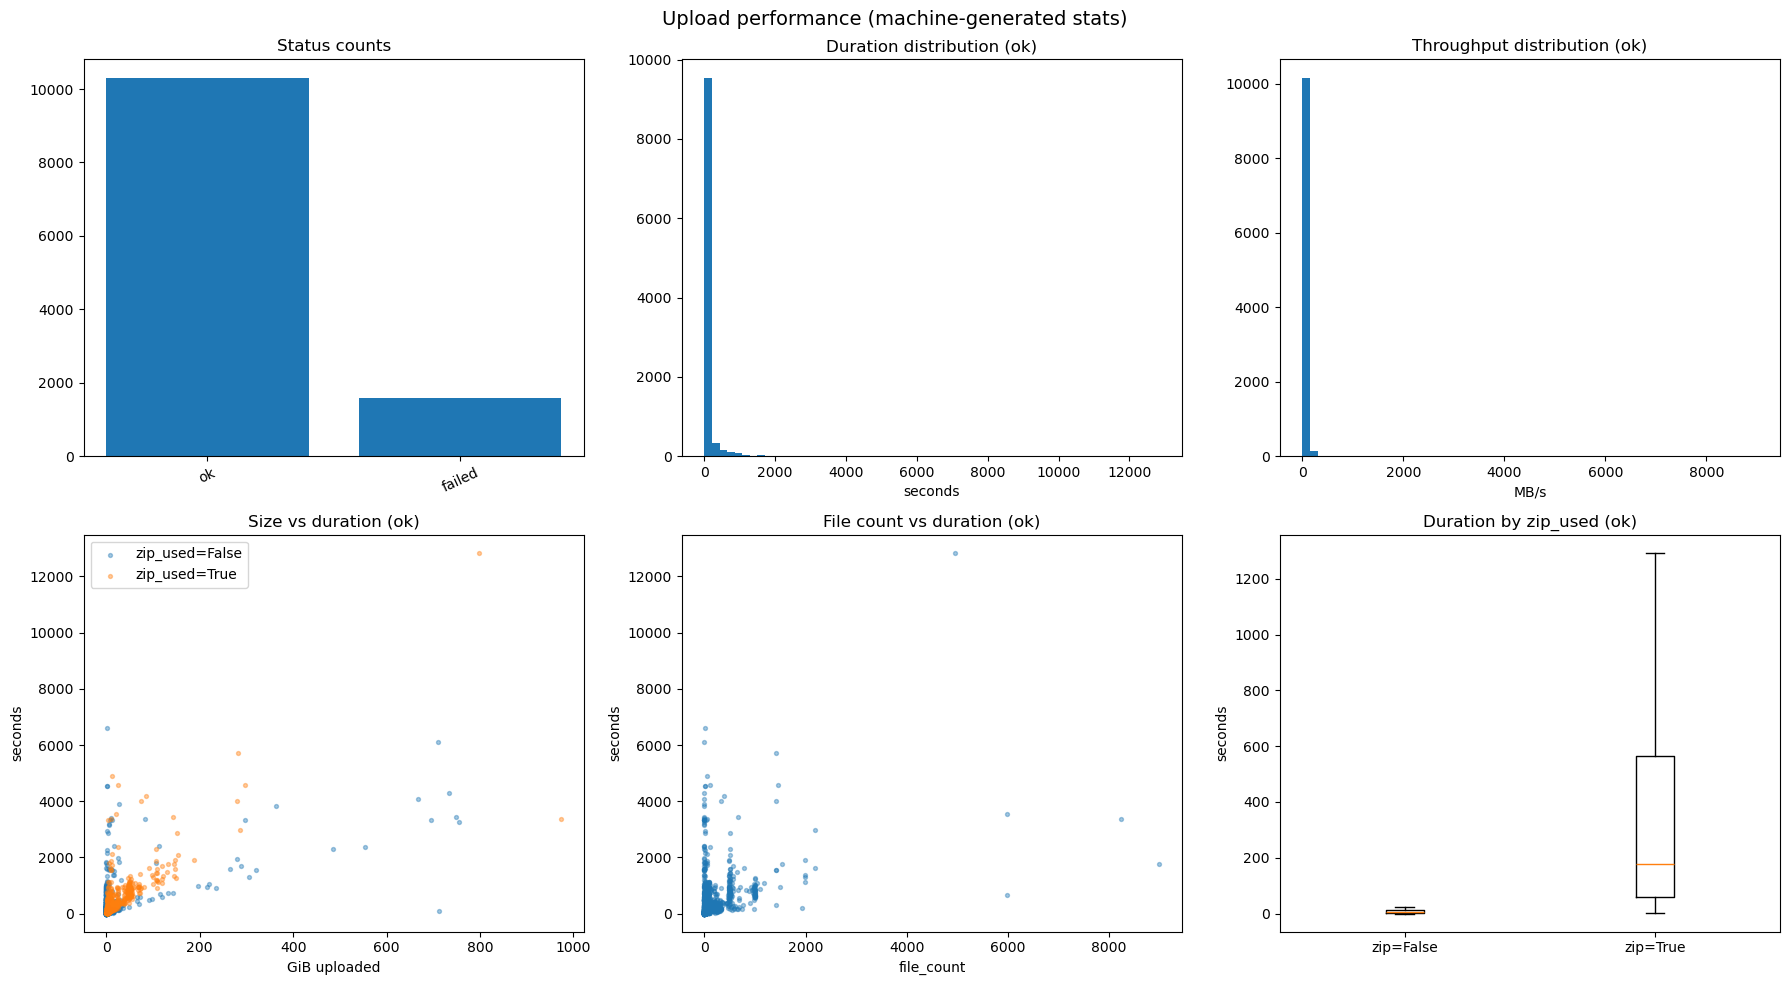

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Upload performance (machine-generated stats)", fontsize=14)

# 1) status count
sc = d["status"].value_counts(dropna=False)
axes[0, 0].bar(sc.index.astype(str), sc.values)
axes[0, 0].set_title("Status counts")
axes[0, 0].tick_params(axis="x", rotation=25)

# 2) duration histogram
axes[0, 1].hist(d.loc[ok_mask, "duration_s"].dropna(), bins=60)
axes[0, 1].set_title("Duration distribution (ok)")
axes[0, 1].set_xlabel("seconds")

# 3) throughput histogram
thr = d.loc[ok_mask, "throughput_MBps"].replace([np.inf, -np.inf], np.nan).dropna()
axes[0, 2].hist(thr, bins=60)
axes[0, 2].set_title("Throughput distribution (ok)")
axes[0, 2].set_xlabel("MB/s")

# 4) bytes vs duration
pts = d.loc[ok_mask, ["bytes_uploaded_GiB", "duration_s", "zip_used"]].dropna()
axes[1, 0].scatter(
    pts.loc[~pts["zip_used"], "bytes_uploaded_GiB"],
    pts.loc[~pts["zip_used"], "duration_s"],
    s=8,
    alpha=0.4,
    label="zip_used=False",
)
axes[1, 0].scatter(
    pts.loc[pts["zip_used"], "bytes_uploaded_GiB"],
    pts.loc[pts["zip_used"], "duration_s"],
    s=8,
    alpha=0.4,
    label="zip_used=True",
)
axes[1, 0].set_title("Size vs duration (ok)")
axes[1, 0].set_xlabel("GiB uploaded")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].legend(loc="best")

# 5) file_count vs duration
fd = d.loc[ok_mask, ["file_count", "duration_s"]].dropna()
axes[1, 1].scatter(fd["file_count"], fd["duration_s"], s=8, alpha=0.4)
axes[1, 1].set_title("File count vs duration (ok)")
axes[1, 1].set_xlabel("file_count")
axes[1, 1].set_ylabel("seconds")

# 6) zip impact (boxplot duration)
z0 = d.loc[ok_mask & (~d["zip_used"]), "duration_s"].dropna()
z1 = d.loc[ok_mask & d["zip_used"], "duration_s"].dropna()
axes[1, 2].boxplot([z0, z1], labels=["zip=False", "zip=True"], showfliers=False)
axes[1, 2].set_title("Duration by zip_used (ok)")
axes[1, 2].set_ylabel("seconds")

plt.tight_layout()
plt.show()


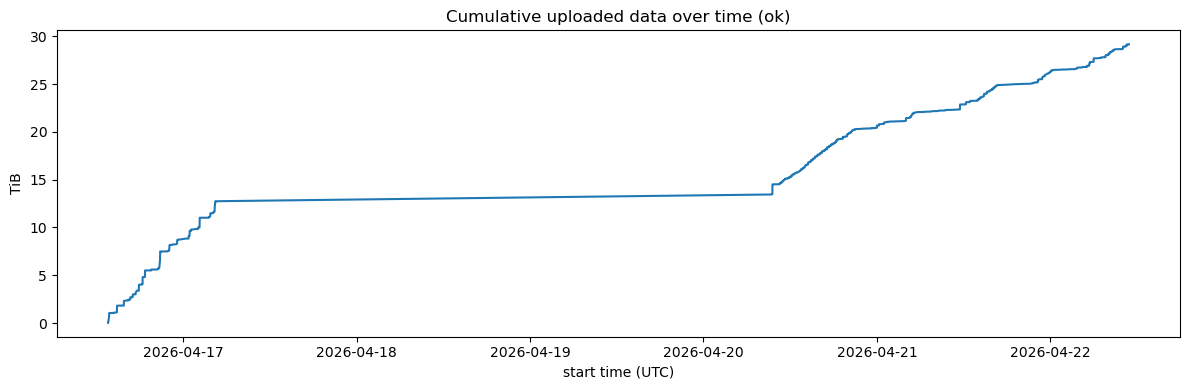

In [41]:
# cumulative uploaded TiB over time (ok only)
t = d.loc[ok_mask, ["start_dt", "bytes_uploaded"]].dropna().sort_values("start_dt").copy()
if not t.empty:
    t["cum_tib"] = t["bytes_uploaded"].cumsum() / (1024**4)
    plt.figure(figsize=(12, 4))
    plt.plot(t["start_dt"], t["cum_tib"])
    plt.title("Cumulative uploaded data over time (ok)")
    plt.xlabel("start time (UTC)")
    plt.ylabel("TiB")
    plt.tight_layout()
    plt.show()


In [42]:
# top slowest and top largest uploads
display_cols = ["recid", "status", "zip_used", "file_count", "bytes_uploaded_GiB", "duration_s", "throughput_MBps", "error"]
print("Top 20 slowest:")
display(d[display_cols].sort_values("duration_s", ascending=False).head(20))

print("Top 20 largest:")
display(d[display_cols].sort_values("bytes_uploaded_GiB", ascending=False).head(20))


Top 20 slowest:


,recid,status,zip_used,file_count,bytes_uploaded_GiB,duration_s,throughput_MBps,error
153,83114,ok,True,4955,799.009027,12843.112,63.706152,
97,82644,ok,False,13,1.725168,6598.058,0.267741,
92,82627,ok,False,1,709.905737,6099.467,119.181475,
155,85342,ok,True,1423,282.551499,5714.745,50.629159,
156,85352,ok,True,52,11.468101,4899.153,2.397013,
154,85331,ok,True,112,24.903643,4591.317,5.554252,
183,88805,ok,True,1457,296.303138,4562.343,66.504078,
184,88813,ok,False,9,1.854043,4547.057,0.417532,
185,88814,ok,False,7,0.765367,4545.840,0.172407,
89,82572,ok,False,1,734.453300,4276.608,175.859040,


Top 20 largest:


,recid,status,zip_used,file_count,bytes_uploaded_GiB,duration_s,throughput_MBps,error
274,92941,ok,True,8248,974.055311,3352.835,297.489330,
153,83114,ok,True,4955,799.009027,12843.112,63.706152,
110,83067,ok,False,1,755.925897,3273.133,236.491496,
182,88788,ok,False,1,748.637806,3436.616,223.069762,
89,82572,ok,False,1,734.453300,4276.608,175.859040,
260,90440,ok,False,1,712.522601,81.015,9006.025347,
92,82627,ok,False,1,709.905737,6099.467,119.181475,
15,81435,ok,False,1,694.742212,3319.574,214.309434,
253,90396,ok,False,1,666.965992,4089.957,166.987862,
6,81073,ok,False,1,554.767073,2372.731,239.420939,


In [2]:
man1_path = "../stats/manifest1.txt"
man2_path = "../stats/manifest2.txt"


In [3]:
def _normalize_manifest_path(p: str) -> str:
    p = str(p).strip()
    parts = p.split("/", 1)
    return parts[1] if len(parts) == 2 else parts[0]

def _load_manifest(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("|")
            if len(parts) < 2:
                continue
            raw_path = parts[0].strip()
            size = pd.to_numeric(parts[1], errors="coerce")  # keep size, ignore timestamp
            rows.append(
                {
                    "raw_path": raw_path,
                    "norm_path": _normalize_manifest_path(raw_path),
                    "size": np.nan if pd.isna(size) else int(size),
                }
            )
    return pd.DataFrame(rows)

m1 = _load_manifest(man1_path)
m2 = _load_manifest(man2_path)

print(f"manifest1 rows: {len(m1):,}")
print(f"manifest2 rows: {len(m2):,}")
m1.head()


manifest1 rows: 307,426
manifest2 rows: 414,750


,raw_path,norm_path,size
0,downloads/90796/hzha03pyth6156_hzcq_206.5_10_4...,90796/hzha03pyth6156_hzcq_206.5_10_4_1053.xsdst,22963200
1,downloads/90796/hzha03pyth6156_hzcq_206.5_10_4...,90796/hzha03pyth6156_hzcq_206.5_10_4_1056.xsdst,67660800
2,downloads/90796/hzha03pyth6156_hzcq_206.5_10_4...,90796/hzha03pyth6156_hzcq_206.5_10_4_1052.xsdst,67722240
3,downloads/90796/hzha03pyth6156_hzcq_206.5_10_4...,90796/hzha03pyth6156_hzcq_206.5_10_4_1057.xsdst,66984960
4,downloads/90796/hzha03pyth6156_hzcq_206.5_10_4...,90796/hzha03pyth6156_hzcq_206.5_10_4_1050.xsdst,67292160


In [4]:
# Ignore all folders that contain xxx_bundle.zip (in either manifest)
def _folders_with_bundle_zip(df: pd.DataFrame) -> set[str]:
    mask = df["norm_path"].astype(str).str.contains(r".*_bundle\.zip$", regex=True, na=False)
    return set(df.loc[mask, "norm_path"].str.rsplit("/", n=1).str[0])

def _drop_folders(df: pd.DataFrame, folders: set[str]) -> pd.DataFrame:
    parents = df["norm_path"].astype(str).str.rsplit("/", n=1).str[0]
    return df.loc[~parents.isin(folders)].copy()

ignored_folders = _folders_with_bundle_zip(m1) | _folders_with_bundle_zip(m2)

m1_no_bundle = _drop_folders(m1, ignored_folders)
m2_no_bundle = _drop_folders(m2, ignored_folders)

print(f"Ignored folders: {len(ignored_folders):,}")
print(f"manifest1 filtered rows: {len(m1_no_bundle):,} / {len(m1):,}")
print(f"manifest2 filtered rows: {len(m2_no_bundle):,} / {len(m2):,}")

# Use filtered manifests for subsequent comparison cells
m1 = m1_no_bundle
m2 = m2_no_bundle


Ignored folders: 218
manifest1 filtered rows: 298,961 / 307,426
manifest2 filtered rows: 298,969 / 414,750


In [5]:
# Exact compare by (normalized path + size), timestamp ignored
kcols = ["norm_path", "size"]
m1k = m1[kcols].drop_duplicates()
m2k = m2[kcols].drop_duplicates()

only_m1 = m1k.merge(m2k, on=kcols, how="left", indicator=True).query("_merge == 'left_only'").drop(columns="_merge")
only_m2 = m2k.merge(m1k, on=kcols, how="left", indicator=True).query("_merge == 'left_only'").drop(columns="_merge")

# Size mismatch compare by normalized path only
s1 = m1.groupby("norm_path", dropna=False)["size"].agg(lambda x: tuple(sorted(set([int(v) for v in x.dropna().tolist()])))).rename("sizes_m1")
s2 = m2.groupby("norm_path", dropna=False)["size"].agg(lambda x: tuple(sorted(set([int(v) for v in x.dropna().tolist()])))).rename("sizes_m2")
size_cmp = pd.concat([s1, s2], axis=1)
size_mismatch = size_cmp[
    size_cmp["sizes_m1"].notna() &
    size_cmp["sizes_m2"].notna() &
    (size_cmp["sizes_m1"] != size_cmp["sizes_m2"])
].reset_index()

summary_cmp = pd.DataFrame(
    {
        "metric": [
            "manifest1_unique_(path,size)",
            "manifest2_unique_(path,size)",
            "only_in_manifest1_(path,size)",
            "only_in_manifest2_(path,size)",
            "size_mismatch_same_norm_path",
        ],
        "value": [
            len(m1k),
            len(m2k),
            len(only_m1),
            len(only_m2),
            len(size_mismatch),
        ],
    }
)
summary_cmp


,metric,value
0,"manifest1_unique_(path,size)",298961
1,"manifest2_unique_(path,size)",298969
2,"only_in_manifest1_(path,size)",1
3,"only_in_manifest2_(path,size)",9
4,size_mismatch_same_norm_path,0


In [6]:
print("Only in manifest1 (sample):")
display(only_m1.head(50))

print("Only in manifest2 (sample):")
display(only_m2.head(50))

print("Same normalized path but different size sets (sample):")
display(size_mismatch.head(50))


Only in manifest1 (sample):


,norm_path,size
87340,417/DELPHI_Data_preservation-8.pdf,45811


Only in manifest2 (sample):


,norm_path,size
3592,80509/DBcalb.dat,1497251840
3593,80509/DBmisc.dat,40960
3594,80509/DBgeom.dat,32432128
3595,80509/DBlepm.dat,1655250944
3596,80509/DBscon.dat,450560
3597,80509/DBrunt.dat,20307968
3598,80509/DBsysf.dat,131072
92416,83967/run17640.xsdst,15482880
92567,83967/run17609.xsdst,15283200


Same normalized path but different size sets (sample):


,norm_path,sizes_m1,sizes_m2
